# 04 - Análise descritiva dos resultados

Carrega o CSV bruto gerado por `python -m src.pipeline.run_all` e produz:
1. Tabela-resumo com média e desvio das métricas por modelo.
2. Gráfico de barras da métrica principal (AUC OVO).
3. Boxplot da métrica por modelo.
4. Análise por regime (tamanho, número de classes, proporção categórica, missing).
5. Custo computacional vs. desempenho.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))

import pandas as pd

from data.load_tabarena import summarize, RECOMMENDED_TASK_IDS
from src.reports.results_table import summary_by_model
from src.reports.plots import (
    bar_metric_by_model,
    boxplot_metric_by_model,
    bar_metric_by_regime,
    time_vs_quality,
)
from src.pipeline.regime import assign_regimes

In [2]:
raw = pd.read_csv('../results/raw.csv')
raw_train = raw[raw["split"] == "train"]
raw_test = raw[raw["split"] == "test"]
raw_train.head()

,task_id,dataset,model,split,auc_ovo,accuracy,g_mean,cross_entropy,fit_time_s,predict_time_s,total_time_s
1,10101,blood-transfusion-service-center,lightgbm,train,0.811201,0.826004,0.626686,0.426470,0.271504,0.033809,0.305312
3,10101,blood-transfusion-service-center,xgboost,train,0.909562,0.873805,0.735602,0.327615,3.142245,0.042921,3.185166
5,10101,blood-transfusion-service-center,catboost,train,0.912756,0.891013,0.769878,0.309543,6.503787,0.019074,6.522861
7,10101,blood-transfusion-service-center,tabm,train,0.784754,0.804971,0.561160,0.446258,11.814747,0.327694,12.142442
9,37,diabetes,lightgbm,train,0.892605,0.821229,0.776862,0.404559,0.278299,0.042431,0.320729


## 1. Tabela-resumo por modelo

In [3]:
summary = summary_by_model(raw)
summary

,model,auc_ovo_mean,auc_ovo_std,accuracy_mean,accuracy_std,g_mean_mean,g_mean_std,cross_entropy_mean,cross_entropy_std,total_time_s_mean,total_time_s_std
3,xgboost,0.898851,0.092312,0.859121,0.103985,0.705040,0.222081,0.457364,0.393137,6.229134,4.301824
2,tabm,0.887259,0.089995,0.835824,0.124130,0.728860,0.150349,0.362322,0.236629,45.489242,68.442238
1,lightgbm,0.877707,0.080343,0.826550,0.110420,0.616770,0.256701,0.413252,0.215671,8.771807,23.156803
0,catboost,0.863761,0.112396,0.831443,0.116826,0.662238,0.230022,0.774285,1.060645,6.401355,2.618733


## 2. Gráfico de barras (AUC OVO)

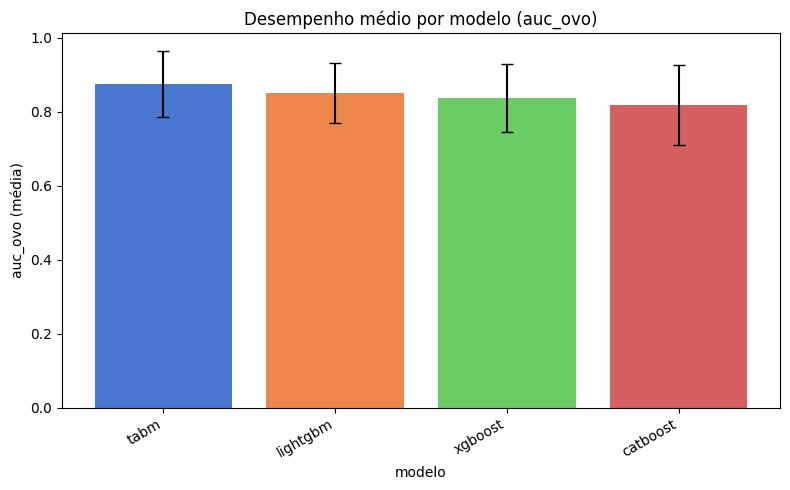

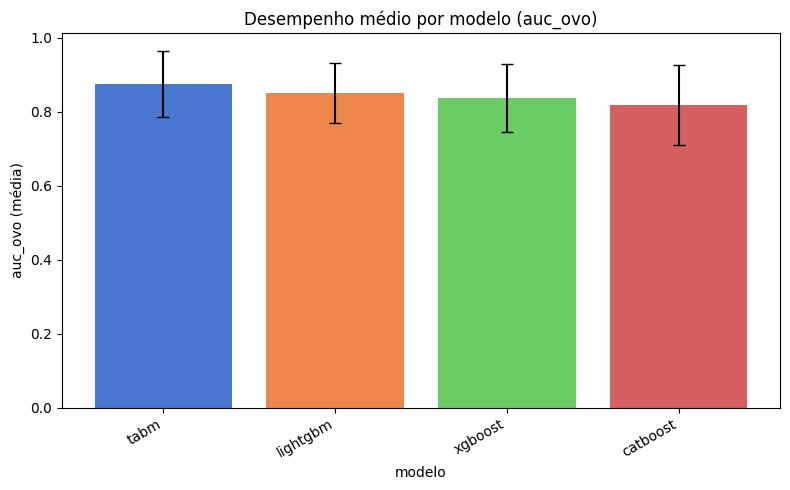

In [4]:
fig = bar_metric_by_model(raw_test, metric='auc_ovo', output_path=Path('../results/figures/bar_auc_test.png'))
fig

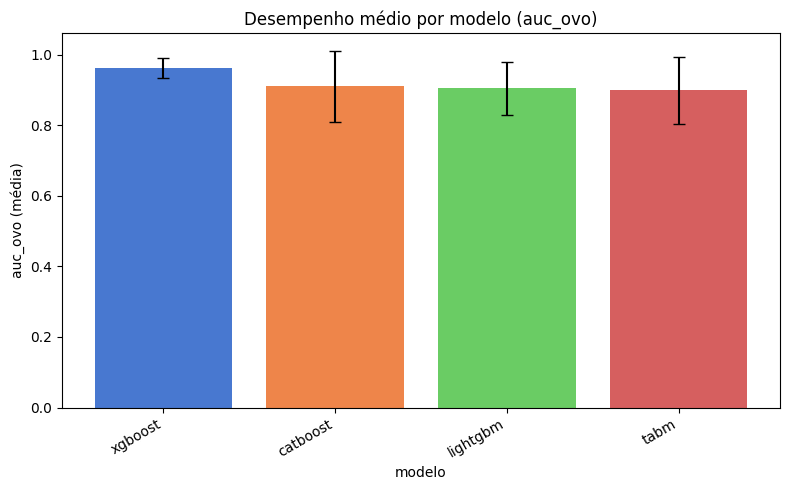

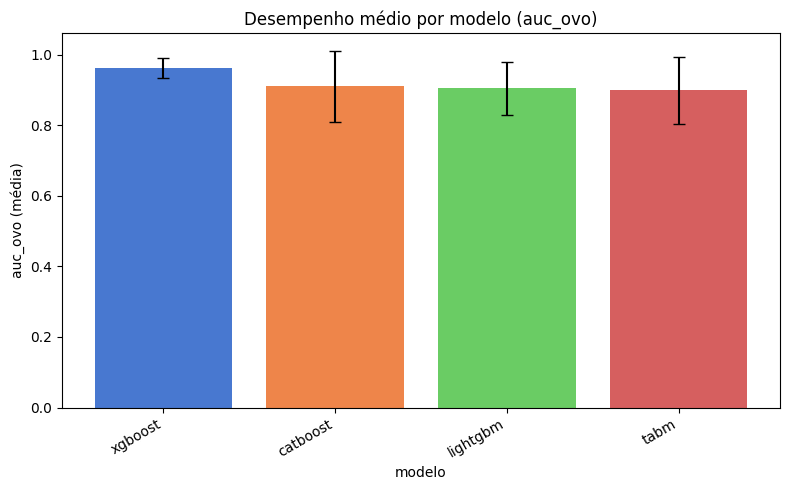

In [5]:
fig = bar_metric_by_model(raw_train, metric='auc_ovo', output_path=Path('../results/figures/bar_auc_train.png'))
fig

## 3. Boxplot por modelo

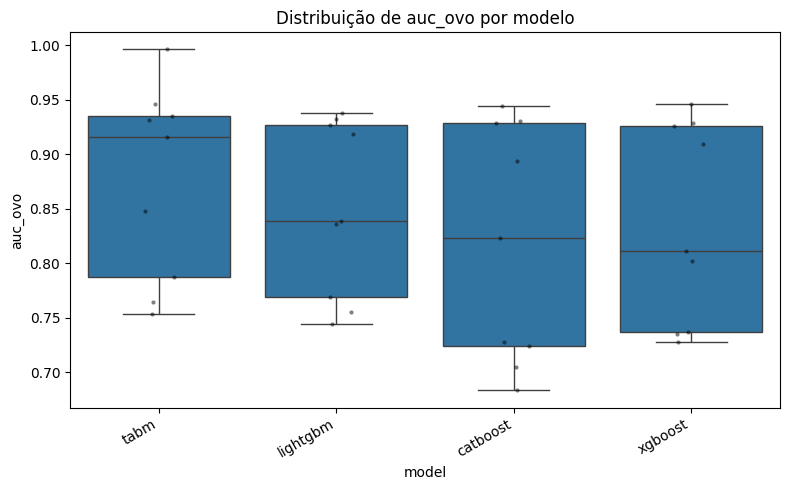

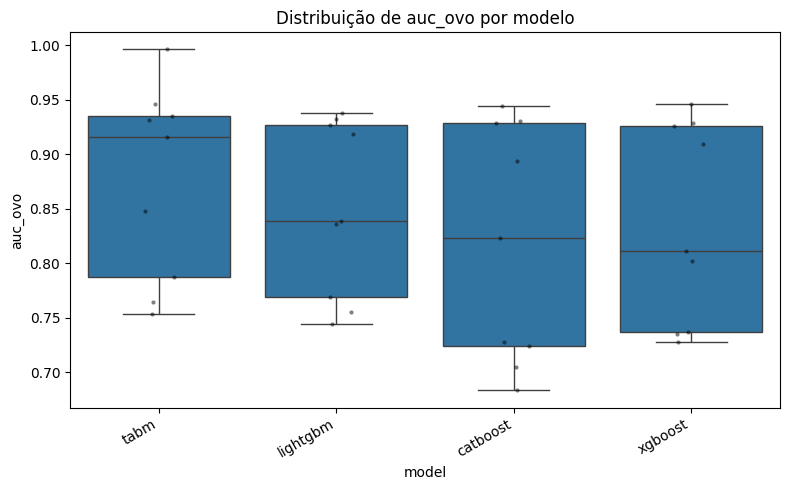

In [6]:
fig = boxplot_metric_by_model(raw_test, metric='auc_ovo', output_path=Path('../results/figures/box_auc_test.png'))
fig

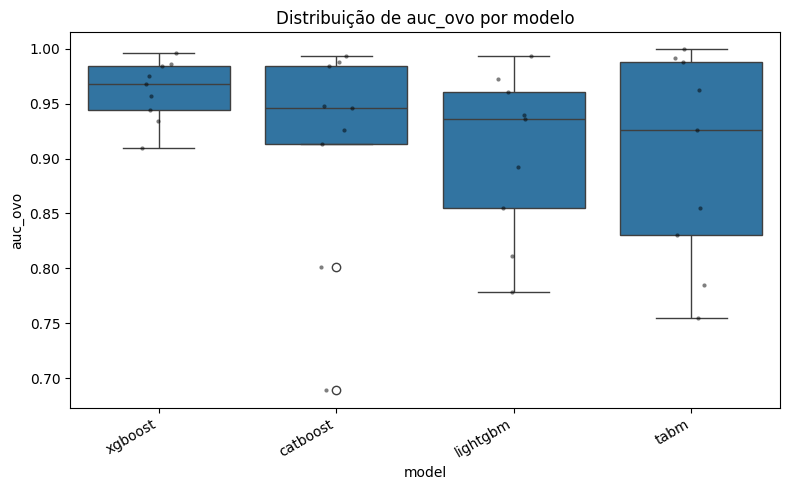

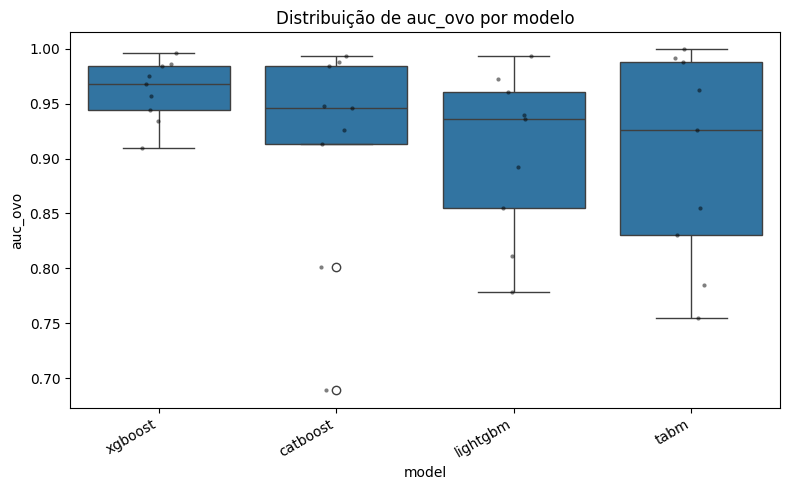

In [7]:
fig = boxplot_metric_by_model(raw_train, metric='auc_ovo', output_path=Path('../results/figures/box_auc_train.png'))
fig

## 4. Análise por regime

In [8]:
metadata = assign_regimes(summarize(RECOMMENDED_TASK_IDS))
metadata

,task_id,name,n_samples,n_features,n_classes,n_categorical,has_missing,regime,regime_size,regime_classes,regime_cat_share,regime_missing
0,10101,blood-transfusion-service-center,748,4,2,0,False,small,small,binary,low,no
1,37,diabetes,768,8,2,0,False,small,small,binary,low,no
2,11,balance-scale,625,4,3,0,False,small,small,multiclass,low,no
3,31,credit-g,1000,20,2,13,False,medium,medium,binary,high,no
4,9952,phoneme,5404,5,2,0,False,medium,medium,binary,low,no
5,23,cmc,1473,9,3,7,False,medium,medium,multiclass,high,no
6,7592,adult,48842,14,2,8,True,large,large,binary,high,yes
7,14965,bank-marketing,45211,16,2,9,False,large,large,binary,high,no
8,146195,connect-4,67557,42,3,42,False,large,large,multiclass,high,no


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\465106387.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\465106387.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\465106387.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\465106387.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


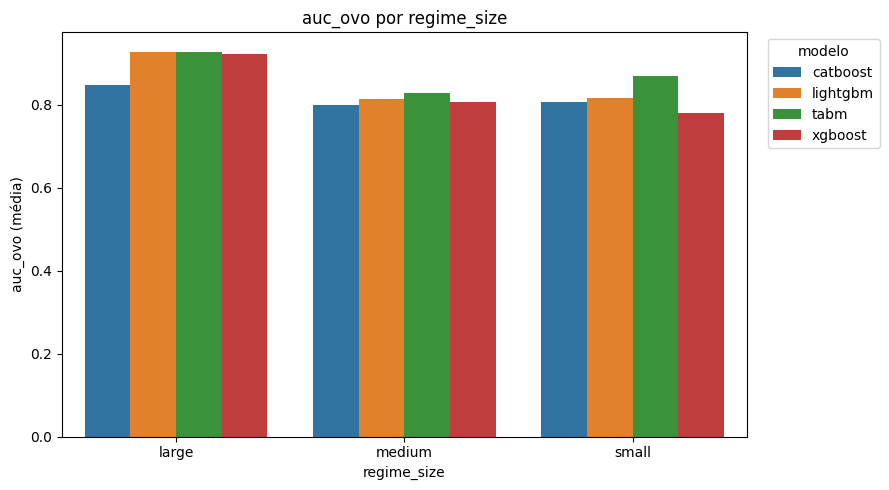

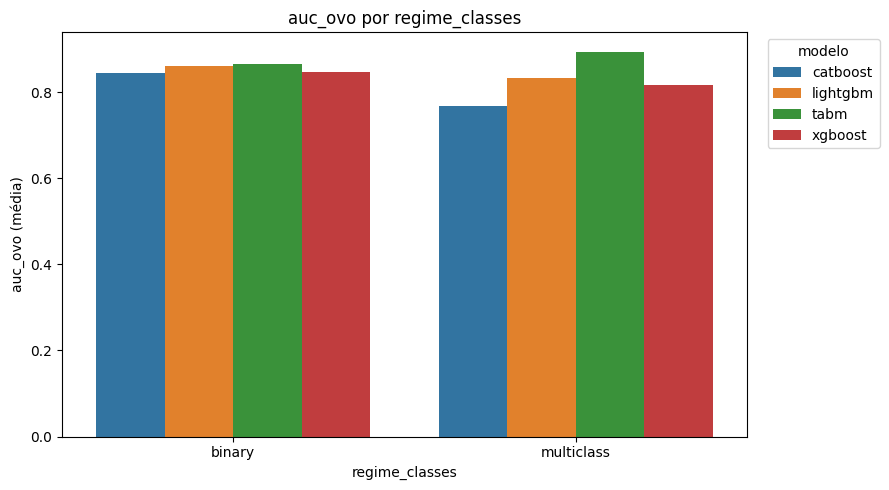

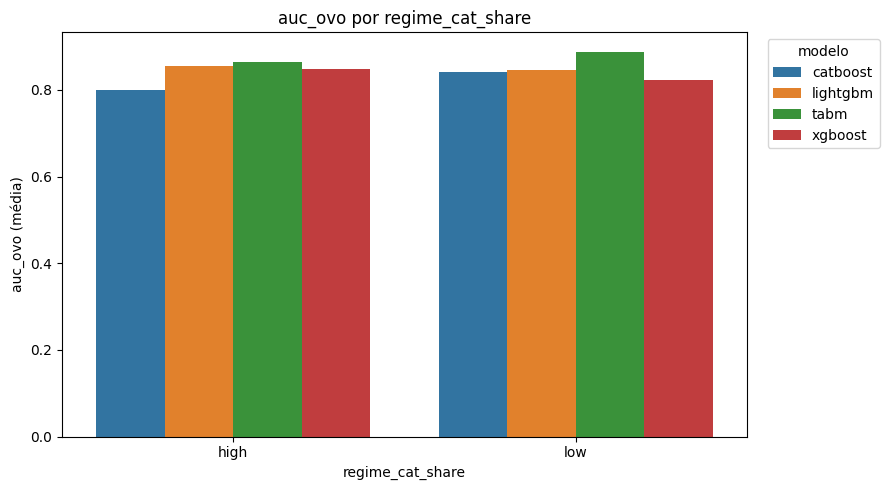

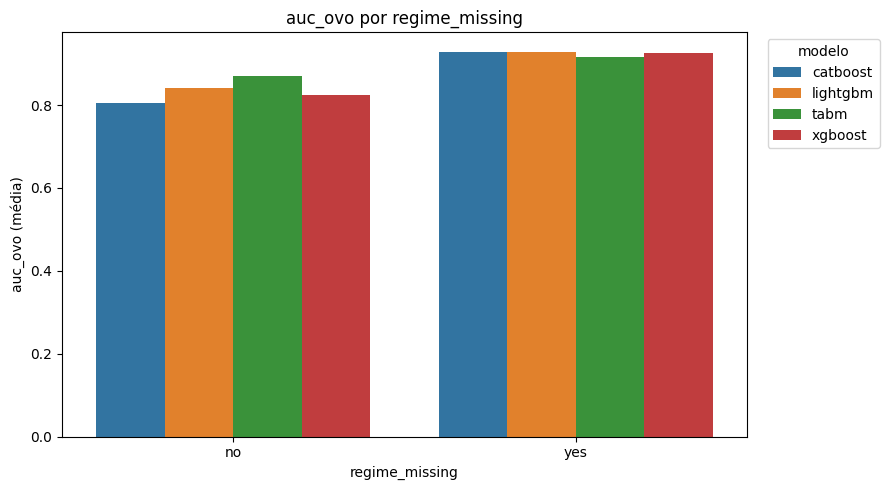

In [9]:
for col in ['regime_size', 'regime_classes', 'regime_cat_share', 'regime_missing']:
    fig = bar_metric_by_regime(
        raw_test, metadata, regime_col=col, metric='auc_ovo',
        output_path=Path(f'../results/figures/regime_{col}_test.png'),
    )
    fig.suptitle('')
    fig.show()
   

C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\1411688712.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\1411688712.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\1411688712.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


C:\Users\vlade\AppData\Local\Temp\ipykernel_97308\1411688712.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


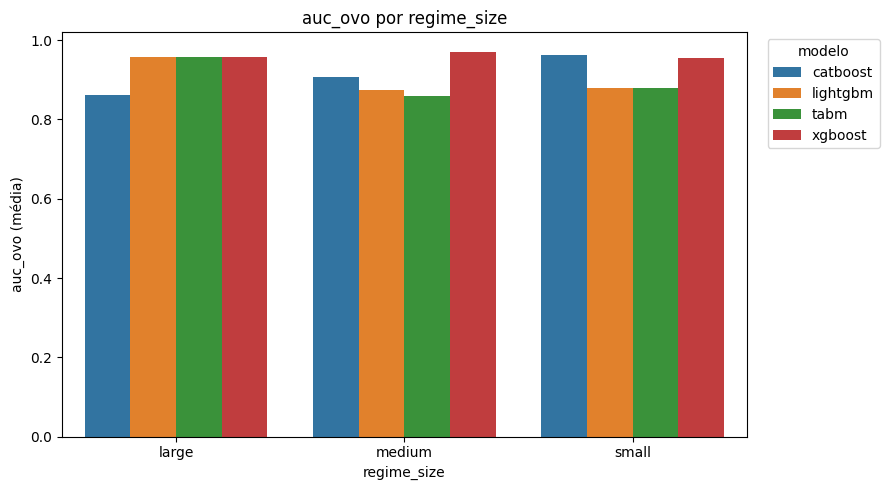

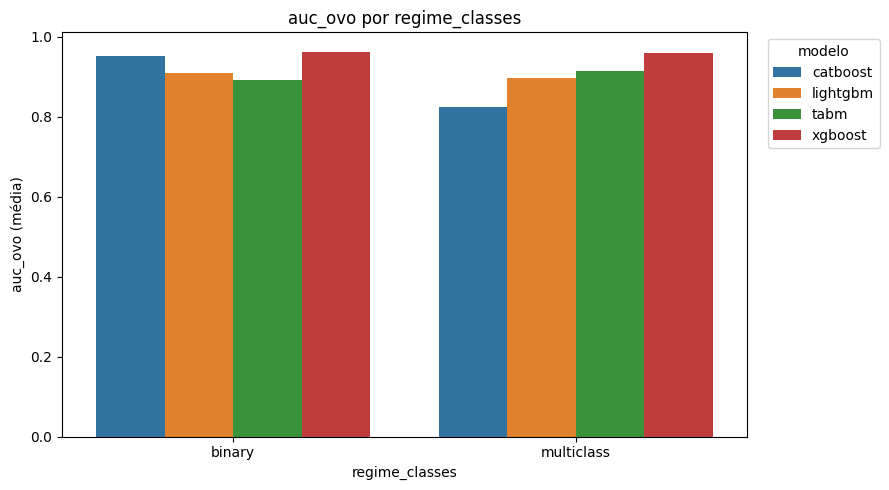

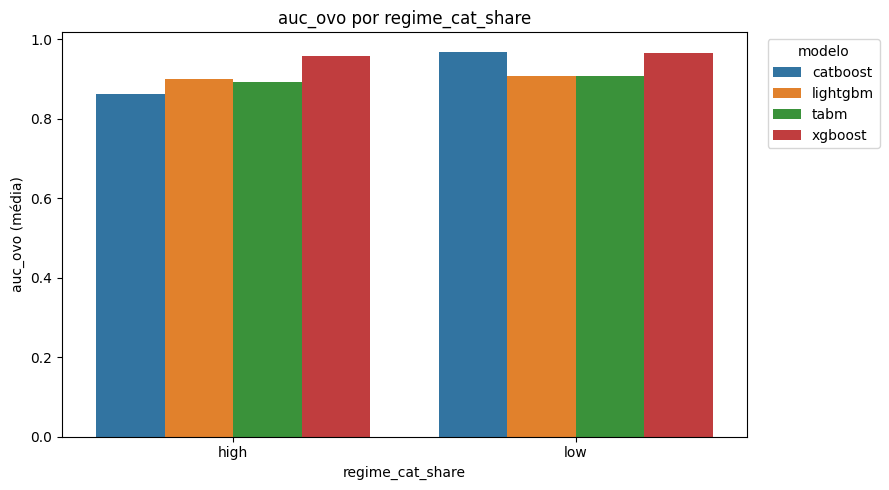

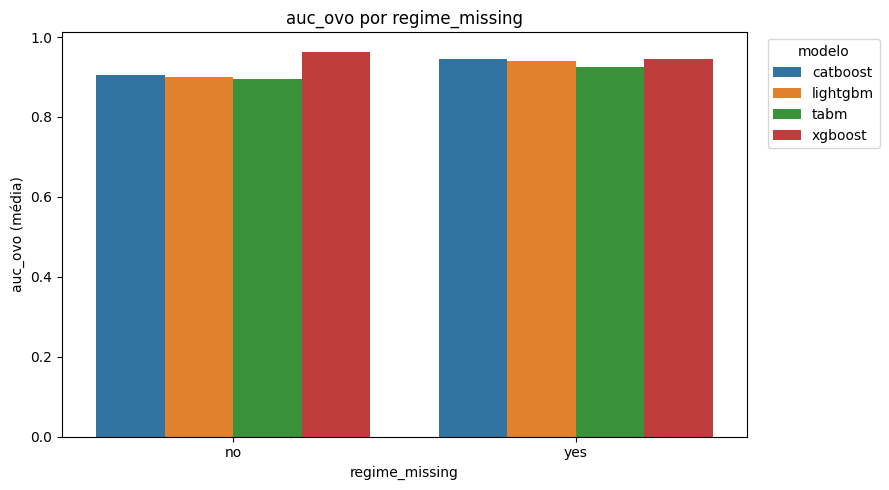

In [10]:
for col in ['regime_size', 'regime_classes', 'regime_cat_share', 'regime_missing']:
    fig = bar_metric_by_regime(
        raw_train, metadata, regime_col=col, metric='auc_ovo',
        output_path=Path(f'../results/figures/regime_{col}_train.png'),
    )
    fig.suptitle('')
    fig.show()
   

## 5. Custo computacional vs. desempenho

In [11]:
print(raw.groupby('model')['total_time_s'].agg(['mean','sum']).round(1).to_string())

          mean    sum
model                
catboost   6.4  115.2
lightgbm   8.8  157.9
tabm      45.5  818.8
xgboost    6.2  112.1


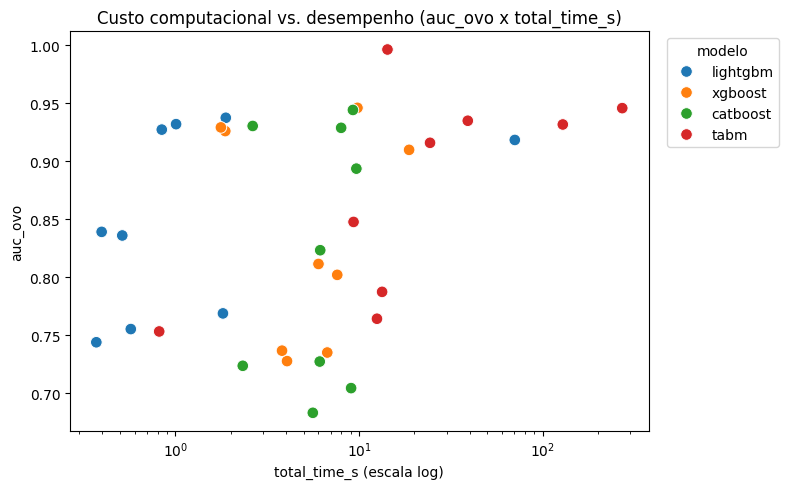

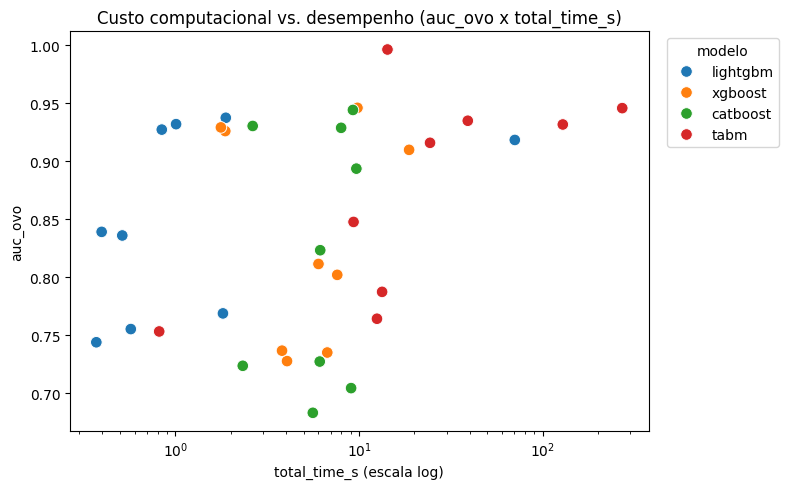

In [12]:
fig = time_vs_quality(raw_test, x='total_time_s', y='auc_ovo', output_path=Path('../results/figures/time_vs_quality_test.png'))
fig

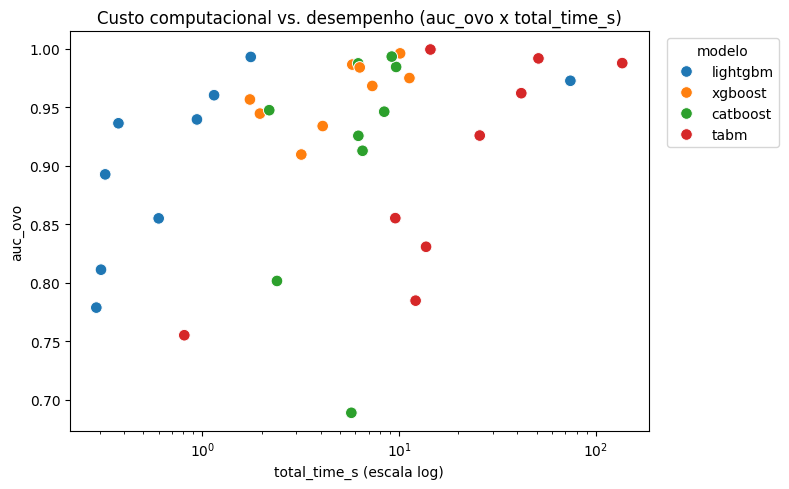

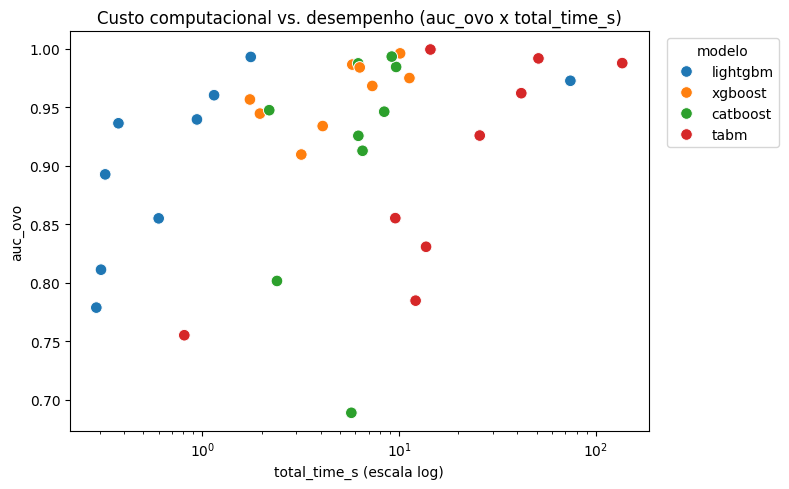

In [13]:
fig = time_vs_quality(raw_train, x='total_time_s', y='auc_ovo', output_path=Path('../results/figures/time_vs_quality_train.png'))
fig

## 6. Ranking do TabM por dataset

In [14]:
pivot = raw.pivot_table(index=['task_id','dataset'], columns='model', values='auc_ovo').reset_index()
cols = ['tabm','catboost','lightgbm','xgboost']
pivot['tabm_rank'] = pivot[cols].rank(axis=1, ascending=False)['tabm'].astype(int)
pivot[['dataset','tabm','lightgbm','catboost','xgboost','tabm_rank']].sort_values('tabm_rank').round(4)

model,dataset,tabm,lightgbm,catboost,xgboost,tabm_rank
0,balance-scale,0.9978,0.8862,0.9391,0.8852,1
7,bank-marketing,0.9485,0.9462,0.9390,0.9429,1
8,connect-4,0.9597,0.9455,0.6861,0.9424,1
5,phoneme,0.9688,0.9653,0.9688,0.9710,2
2,credit-g,0.8092,0.8053,0.8265,0.8596,3
3,diabetes,0.8515,0.8659,0.9054,0.8990,4
4,adult,0.9209,0.9335,0.9375,0.9353,4
1,cmc,0.7543,0.7615,0.7627,0.8354,4
6,blood-transfusion-service-center,0.7746,0.7901,0.8087,0.8187,4


## 7. Bootstrap IC 95% — TabM

In [15]:
import numpy as np

rng = np.random.default_rng(42)
...
def bootstrap_ci(arr, n=1000):
    means = [np.mean(rng.choice(arr, len(arr), replace=True)) for _ in range(n)]
    return np.percentile(means, [2.5, 97.5])

tabm = raw[raw.model=='tabm']
rows = []
for m in ['auc_ovo','accuracy','g_mean','cross_entropy','total_time_s']:
    v = tabm[m].values
    lo, hi = bootstrap_ci(v)
    rows.append({'Métrica':m,'Média':f'{v.mean():.4f}','DP':f'{v.std():.4f}','IC 95%':f'[{lo:.4f}; {hi:.4f}]'})
pd.DataFrame(rows)

,Métrica,Média,DP,IC 95%
0,auc_ovo,0.8873,0.0875,[0.8468; 0.9276]
1,accuracy,0.8358,0.1206,[0.7784; 0.8869]
2,g_mean,0.7289,0.1461,[0.6637; 0.7985]
3,cross_entropy,0.3623,0.2300,[0.2636; 0.4723]
4,total_time_s,45.4892,66.5139,[19.4327; 79.8074]
